<a href="https://colab.research.google.com/github/ugisrutinsRSU/RSU_Colab/blob/main/04_Regularization_and_Optimization_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularisation and Optimisation: House Price Regression

## Overview

In this exercise you will build a **regression neural network** in PyTorch to predict median house prices from census data. Along the way you will apply and compare the regularisation and optimisation techniques introduced in the lecture.

**By the end of this exercise you will have practiced:**
- Building a regression neural network (no sigmoid output — continuous prediction)
- Applying dropout and L2 weight decay to reduce overfitting
- Comparing three optimisers: SGD, Adam, and RMSprop
- Evaluating regression quality with MSE and MAE
- Visualising predictions against ground truth

---

## Dataset: California Housing

The **California Housing dataset** is built into scikit-learn and requires no download. It contains 20,640 census block groups from the 1990 California census.

| Feature | Description |
|---|---|
| `MedInc` | Median income in the block group (in tens of thousands of USD) |
| `HouseAge` | Median house age in the block group |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average household occupancy |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |

**Target:** `MedHouseVal` — median house value in hundreds of thousands of USD.

### Key characteristics to keep in mind
- `Population` and `AveOccup` contain extreme outliers (some block groups have very unusual values). This makes feature scaling especially important.
- `Latitude` and `Longitude` encode spatial structure (coastal vs inland, north vs south). A neural network can learn non-linear combinations of these, unlike linear models.
- The target is **capped at 5.0** — the original dataset clips very high-value properties. This means the model will underestimate top-tier prices slightly, which is expected.

## Step 1 — Imports

Import everything you will need upfront. For this exercise you need:
- `numpy`, `pandas`, `matplotlib.pyplot`
- From `sklearn`: `fetch_california_housing`, `train_test_split`, `StandardScaler`
- From `sklearn.metrics`: `mean_squared_error`, `mean_absolute_error`
- `torch`, `torch.nn`, `torch.optim`
- From `torch.utils.data`: `TensorDataset`, `DataLoader`

Also fix random seeds for reproducibility: `torch.manual_seed(42)` and `np.random.seed(42)`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Fix random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## Step 2 — Load and Explore the Data

Load the dataset using `fetch_california_housing(as_frame=True)` from scikit-learn. This returns a `Bunch` object — access `.frame` to get a single pandas DataFrame with both features and target.

**Tasks:**
1. Load the dataset and display the first few rows.
2. Print the shape and check for missing values.
3. Print summary statistics (`.describe()`). Pay attention to `Population` and `AveOccup` — do their max values look unusual compared to the mean?
4. Plot a histogram of the target column `MedHouseVal`. Notice the spike at 5.0 — this is the cap described above.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("First few rows:")
print(df.head())

First few rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")
print("\nSummary statistics:")
print(df.describe())

Shape: (20640, 9)
Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Summary statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
cou

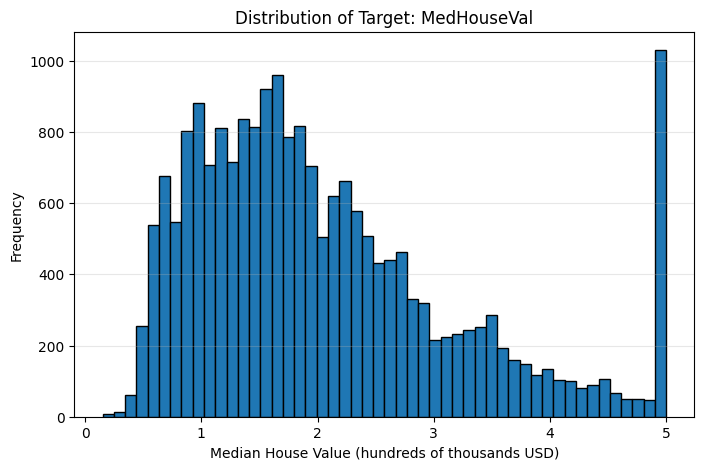

Target min: 0.14999, max: 5.00001


In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black')
plt.xlabel('Median House Value (hundreds of thousands USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Target: MedHouseVal')
plt.grid(axis='y', alpha=0.3)
plt.show()
print(f"Target min: {df['MedHouseVal'].min()}, max: {df['MedHouseVal'].max()}")

## Step 3 — Preprocess the Data

### Feature scaling

All eight features are numeric, so no encoding is needed. However, they vary wildly in scale:
- `MedInc` ranges from roughly 0.5 to 15.
- `Population` ranges from 3 to over 35,000.

Without scaling, the gradient updates for parameters connected to `Population` will dominate those connected to smaller-scale features, destabilising training. Use **`StandardScaler`** (zero mean, unit variance).

> **Important:** fit the scaler only on training features, then apply the fitted scaler to the test set. Fitting on the full dataset would leak test-set statistics into training.

**Tasks:**
1. Separate features (`X`) and target (`y`) as NumPy arrays.
2. Split into train (80 %) and test (20 %) sets with `random_state=42`.
3. Fit `StandardScaler` on `X_train` and transform both `X_train` and `X_test`.
4. Convert all four arrays to `torch.FloatTensor`.
5. Wrap into `TensorDataset` objects and create `DataLoader`s with `batch_size=64`, `shuffle=True` for train and `shuffle=False` for test.
6. Print the number of training and test samples to confirm the split.

In [5]:
X = df.drop('MedHouseVal', axis=1).values
y = df['MedHouseVal'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (20640, 8), y shape: (20640,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit scaler only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to torch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 16512
Test samples: 4128


## Step 4 — Define the Neural Network

### Regression vs classification — the key difference

In the classification exercise, the output layer used a **Sigmoid** activation to squash the output to (0, 1). For regression we want an **unbounded continuous output**, so the output layer has **no activation function** (or equivalently, a linear activation). The model outputs a raw number that we interpret directly as the predicted house price.

### Architecture requirements

```
Input (8 features)
    → Linear(8  → 64)  → ReLU → Dropout(p)
    → Linear(64 → 32)  → ReLU → Dropout(p)
    → Linear(32 → 1)           ← no activation
```

**Tasks:**
1. Define a class `HousePriceNN(nn.Module)` with:
   - `__init__(self, dropout_rate=0.0, l1_lambda=0.0)` — builds the layers and stores `l1_lambda`.
   - `forward(self, x)` — runs the forward pass.
   - `l1_penalty(self)` — computes the L1 weight penalty over weight matrices only (skip biases). Return `torch.tensor(0.0)` when `l1_lambda == 0` so the method is always safe to add to the loss.
2. Instantiate the model with default settings and print it.
3. Count and print the total number of trainable parameters.

> **Tip:** use `model.named_parameters()` in `l1_penalty` and filter for names containing `"weight"` to exclude biases.

In [7]:
class HousePriceNN(nn.Module):
    def __init__(self, dropout_rate=0.0, l1_lambda=0.0):
        super().__init__()
        self.fc1 = nn.Linear(8, 64)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(32, 1)
        self.l1_lambda = l1_lambda
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc3(x)  # No activation for regression
        return x
    
    def l1_penalty(self):
        l1_loss = torch.tensor(0.0)
        for name, param in self.named_parameters():
            if 'weight' in name:
                l1_loss += torch.sum(torch.abs(param))
        return self.l1_lambda * l1_loss

# Instantiate model
model = HousePriceNN()
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params}")

HousePriceNN(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (dropout1): Dropout(p=0.0, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (dropout2): Dropout(p=0.0, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Total trainable parameters: 2689


## Step 5 — Training Utility

Write a reusable `run_experiment` function so you can run multiple configurations cleanly without copy-pasting the training loop.

**Function signature:**
```python
def run_experiment(label, train_loader, test_loader,
                   dropout_rate=0.0, l1_lambda=0.0, l2_lambda=0.0,
                   optimizer_name="adam", lr=1e-3, epochs=50):
```

**The function should:**
1. Create a fresh `HousePriceNN` with the given `dropout_rate` and `l1_lambda`.
2. Instantiate the chosen optimiser:
   - `"adam"` → `optim.Adam(..., weight_decay=l2_lambda)`
   - `"sgd"` → `optim.SGD(..., momentum=0.9, weight_decay=l2_lambda)`
   - `"rmsprop"` → `optim.RMSprop(..., weight_decay=l2_lambda)`
3. Use `nn.MSELoss()` as the loss criterion.
4. Run a training loop for the given number of epochs:
   - Each batch: `zero_grad → forward → loss + l1_penalty → backward → step`
   - Track average **train MSE** and **test MSE** per epoch.
   - For test loss: use `model.eval()` and `torch.no_grad()`. Evaluate on **raw MSE only** (no penalty) for a fair cross-configuration comparison.
5. After training, compute **test MAE** and **test RMSE**.
6. Print a one-line summary: label, final train MSE, test MSE, test MAE.
7. Return a dict with keys: `label`, `train`, `test`, `mae`, `rmse`.

> **Why MSE for training but report RMSE?** MSE is the loss we optimise (it is differentiable and penalises large errors strongly). RMSE is reported because it is in the same units as the target (hundreds of thousands of USD), making it more interpretable.

In [8]:
def run_experiment(label, train_loader, test_loader,
                   dropout_rate=0.0, l1_lambda=0.0, l2_lambda=0.0,
                   optimizer_name="adam", lr=1e-3, epochs=50):
    """
    Run a training experiment with specified hyperparameters.
    Returns a dict with results.
    """
    # Create model
    model = HousePriceNN(dropout_rate=dropout_rate, l1_lambda=l1_lambda)
    
    # Create optimizer
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_lambda)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=l2_lambda)
    elif optimizer_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=l2_lambda)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")
    
    criterion = nn.MSELoss()
    
    train_losses = []
    test_losses = []
    
    # Training loop
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch) + model.l1_penalty()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Evaluation phase
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)  # MSE only, no penalty
                test_loss += loss.item() * X_batch.size(0)
        
        test_loss /= len(test_loader.dataset)
        test_losses.append(test_loss)
    
    # Compute test metrics
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            all_preds.append(y_pred.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    test_mae = mean_absolute_error(all_targets, all_preds)
    test_rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    
    # Print summary
    print(f"{label:40s} | Train MSE: {train_losses[-1]:.6f} | Test MSE: {test_losses[-1]:.6f} | Test MAE: {test_mae:.6f}")
    
    return {
        'label': label,
        'train': train_losses,
        'test': test_losses,
        'mae': test_mae,
        'rmse': test_rmse,
        'model': model
    }

## Step 6 — Experiment A: Baseline vs Regularisation

Run four configurations using **Adam** at `lr=1e-3` for **50 epochs**, varying only the regularisation:

| Config | Dropout | L1 | L2 (weight decay) |
|---|---|---|---|
| Baseline | — | — | — |
| Dropout | 0.3 | — | — |
| L1 | — | 1e-4 | — |
| L2 | — | — | 1e-4 |

After running all four, write a helper function `plot_loss_curves(results, title)` that:
- Creates one subplot per configuration (1 row, 4 columns, shared y-axis).
- Plots train loss (solid) and test loss (dashed) on each subplot.
- Shades the area between the two curves — a larger shaded area signals more overfitting.
- Labels each subplot with the configuration name and its final test RMSE.
- Sets a shared y-axis label (`"MSE Loss"`) and a figure title.

**What to look for:** Which configuration shows the smallest gap between training and test loss? Does any regularisation method hurt performance (test MSE rises)?

In [9]:
print("=" * 80)
print("EXPERIMENT A: Regularisation Comparison (Adam, lr=1e-3, 50 epochs)")
print("=" * 80)

exp_a_results = []

# Baseline
result = run_experiment(
    "Baseline (no regularisation)",
    train_loader, test_loader,
    dropout_rate=0.0, l1_lambda=0.0, l2_lambda=0.0,
    optimizer_name="adam", lr=1e-3, epochs=50
)
exp_a_results.append(result)

# Dropout
result = run_experiment(
    "Dropout (p=0.3)",
    train_loader, test_loader,
    dropout_rate=0.3, l1_lambda=0.0, l2_lambda=0.0,
    optimizer_name="adam", lr=1e-3, epochs=50
)
exp_a_results.append(result)

# L1
result = run_experiment(
    "L1 (lambda=1e-4)",
    train_loader, test_loader,
    dropout_rate=0.0, l1_lambda=1e-4, l2_lambda=0.0,
    optimizer_name="adam", lr=1e-3, epochs=50
)
exp_a_results.append(result)

# L2
result = run_experiment(
    "L2 (lambda=1e-4)",
    train_loader, test_loader,
    dropout_rate=0.0, l1_lambda=0.0, l2_lambda=1e-4,
    optimizer_name="adam", lr=1e-3, epochs=50
)
exp_a_results.append(result)

EXPERIMENT A: Regularisation Comparison (Adam, lr=1e-3, 50 epochs)
Baseline (no regularisation)             | Train MSE: 0.268711 | Test MSE: 0.281370 | Test MAE: 0.359839
Dropout (p=0.3)                          | Train MSE: 0.351267 | Test MSE: 0.301584 | Test MAE: 0.384001
L1 (lambda=1e-4)                         | Train MSE: 0.290339 | Test MSE: 0.297400 | Test MAE: 0.380764
L2 (lambda=1e-4)                         | Train MSE: 0.251366 | Test MSE: 0.273193 | Test MAE: 0.351397


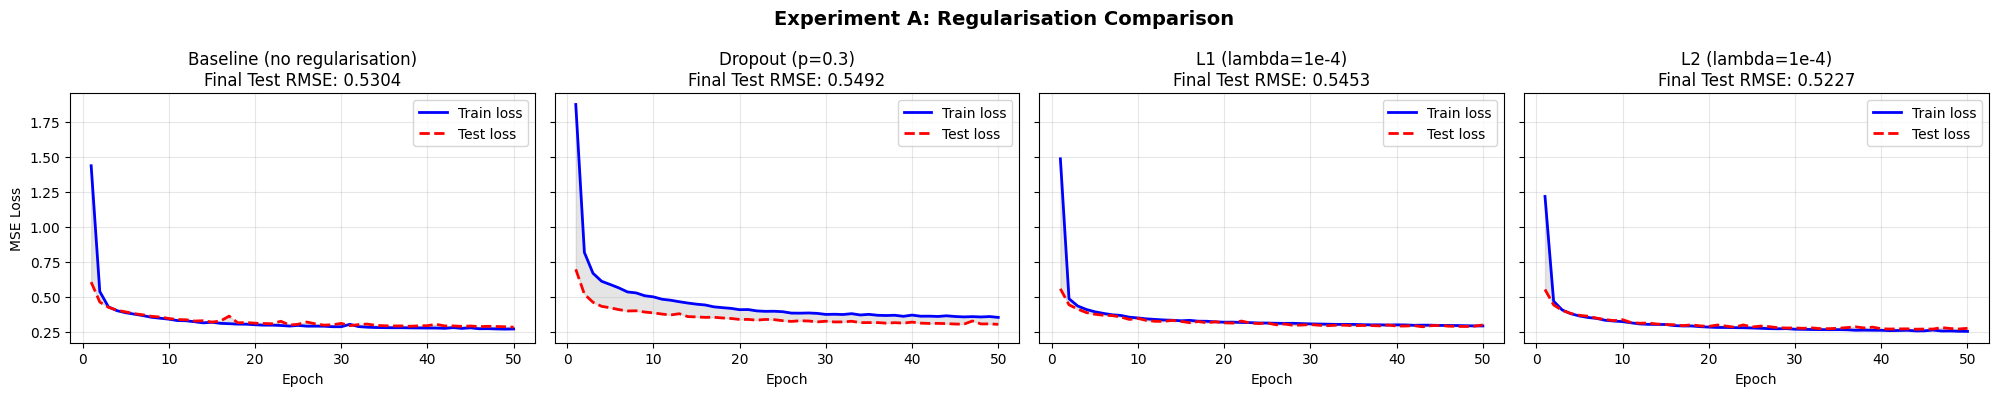

In [10]:
def plot_loss_curves(results, title):
    """
    Plot training and test loss curves for each configuration.
    Shade area between train and test loss to visualise overfitting.
    """
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
    if n == 1:
        axes = [axes]
    
    for ax, result in zip(axes, results):
        train_loss = result['train']
        test_loss = result['test']
        epochs = range(1, len(train_loss) + 1)
        
        ax.plot(epochs, train_loss, 'b-', label='Train loss', linewidth=2)
        ax.plot(epochs, test_loss, 'r--', label='Test loss', linewidth=2)
        ax.fill_between(epochs, train_loss, test_loss, alpha=0.2, color='gray')
        
        ax.set_xlabel('Epoch')
        ax.set_title(f"{result['label']}\nFinal Test RMSE: {result['rmse']:.4f}")
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    axes[0].set_ylabel('MSE Loss')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_loss_curves(exp_a_results, "Experiment A: Regularisation Comparison")

## Step 7 — Experiment B: Optimiser Comparison

Now fix regularisation at **Dropout=0.3** (the most general method) and compare three optimisers at two learning rates each:

| Config | Optimiser | LR |
|---|---|---|
| Adam lr=1e-3 | Adam | 0.001 |
| Adam lr=1e-4 | Adam | 0.0001 |
| SGD lr=1e-2 | SGD | 0.01 |
| SGD lr=1e-3 | SGD | 0.001 |
| RMSprop lr=1e-3 | RMSprop | 0.001 |
| RMSprop lr=1e-4 | RMSprop | 0.0001 |

Run all six and plot them.

**What to look for:**
- Does SGD at `lr=1e-2` converge, oscillate, or diverge?
- How does RMSprop compare to Adam at the same learning rate?
- Which optimiser reaches the lowest test MSE fastest (fewest epochs)?

In [11]:
print("\n" + "=" * 80)
print("EXPERIMENT B: Optimiser Comparison (Dropout=0.3, 50 epochs)")
print("=" * 80)

exp_b_results = []

configs = [
    ("Adam lr=1e-3", "adam", 1e-3),
    ("Adam lr=1e-4", "adam", 1e-4),
    ("SGD lr=1e-2", "sgd", 1e-2),
    ("SGD lr=1e-3", "sgd", 1e-3),
    ("RMSprop lr=1e-3", "rmsprop", 1e-3),
    ("RMSprop lr=1e-4", "rmsprop", 1e-4),
]

for label, optim_name, learning_rate in configs:
    result = run_experiment(
        label,
        train_loader, test_loader,
        dropout_rate=0.3, l1_lambda=0.0, l2_lambda=0.0,
        optimizer_name=optim_name, lr=learning_rate, epochs=50
    )
    exp_b_results.append(result)


EXPERIMENT B: Optimiser Comparison (Dropout=0.3, 50 epochs)
Adam lr=1e-3                             | Train MSE: 0.354380 | Test MSE: 0.303059 | Test MAE: 0.385464
Adam lr=1e-4                             | Train MSE: 0.566183 | Test MSE: 0.417063 | Test MAE: 0.448689
SGD lr=1e-2                              | Train MSE: 0.387214 | Test MSE: 0.317587 | Test MAE: 0.392705
SGD lr=1e-3                              | Train MSE: 0.426615 | Test MSE: 0.353046 | Test MAE: 0.430238
RMSprop lr=1e-3                          | Train MSE: 0.355068 | Test MSE: 0.308098 | Test MAE: 0.388718
RMSprop lr=1e-4                          | Train MSE: 0.499273 | Test MSE: 0.396783 | Test MAE: 0.446893


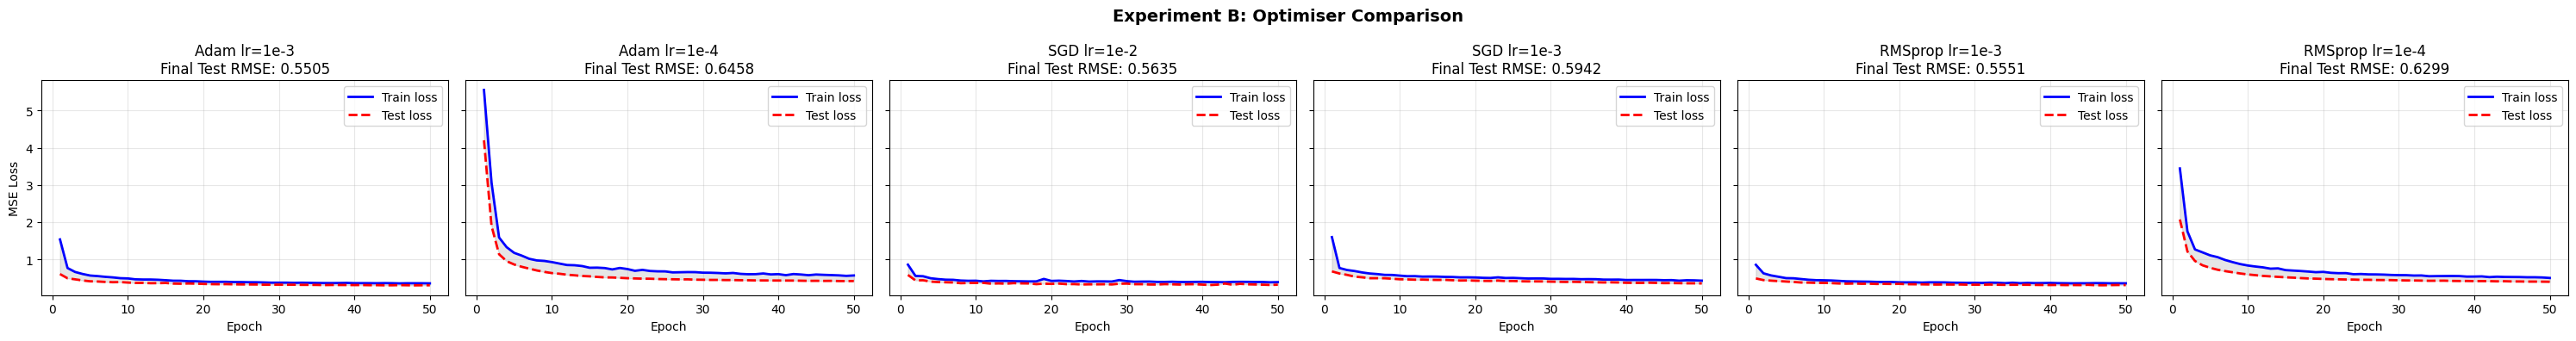

In [12]:
plot_loss_curves(exp_b_results, "Experiment B: Optimiser Comparison")

## Step 8 — Summary Table

Collect all results from both experiments into a single pandas DataFrame with columns:
- `Configuration`
- `Final Train MSE`
- `Final Test MSE`
- `Train-Test Gap` (test MSE − train MSE)
- `Test MAE`
- `Test RMSE`

Print the table. Then print two lines:
- Which configuration achieved the smallest train-test gap.
- Which configuration achieved the lowest test RMSE.

In [13]:
# Combine all results
all_results = exp_a_results + exp_b_results

# Build summary dataframe
summary_data = []
for result in all_results:
    summary_data.append({
        'Configuration': result['label'],
        'Final Train MSE': result['train'][-1],
        'Final Test MSE': result['test'][-1],
        'Train-Test Gap': result['test'][-1] - result['train'][-1],
        'Test MAE': result['mae'],
        'Test RMSE': result['rmse']
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# Find best configurations
best_gap_idx = summary_df['Train-Test Gap'].idxmin()
best_rmse_idx = summary_df['Test RMSE'].idxmin()

print(f"\nSmallest train-test gap: {summary_df.loc[best_gap_idx, 'Configuration']}")
print(f"                        Gap = {summary_df.loc[best_gap_idx, 'Train-Test Gap']:.6f}")
print(f"\nLowest test RMSE: {summary_df.loc[best_rmse_idx, 'Configuration']}")
print(f"                  RMSE = {summary_df.loc[best_rmse_idx, 'Test RMSE']:.6f}")


Summary Table:
               Configuration  Final Train MSE  Final Test MSE  Train-Test Gap  Test MAE  Test RMSE
Baseline (no regularisation)         0.268711        0.281370        0.012659  0.359839   0.530443
             Dropout (p=0.3)         0.351267        0.301584       -0.049683  0.384001   0.549167
            L1 (lambda=1e-4)         0.290339        0.297400        0.007061  0.380764   0.545344
            L2 (lambda=1e-4)         0.251366        0.273193        0.021827  0.351397   0.522679
                Adam lr=1e-3         0.354380        0.303059       -0.051321  0.385464   0.550508
                Adam lr=1e-4         0.566183        0.417063       -0.149120  0.448689   0.645804
                 SGD lr=1e-2         0.387214        0.317587       -0.069627  0.392705   0.563549
                 SGD lr=1e-3         0.426615        0.353046       -0.073569  0.430238   0.594176
             RMSprop lr=1e-3         0.355068        0.308098       -0.046971  0.388718   0.5

## Step 9 — Visualise Predictions

Take the best-performing configuration from your summary table and produce a **scatter plot of predicted vs actual house prices** on the test set.

**Tasks:**
1. Retrain (or reuse) the best model.
2. Run inference on the full test set to collect predicted values.
3. Create a scatter plot:
   - x-axis: actual `MedHouseVal`
   - y-axis: predicted `MedHouseVal`
   - Draw a diagonal dashed line representing perfect prediction (`y = x`). Points close to this line indicate good predictions.
   - Colour points by prediction error magnitude (use `c=abs(pred - actual)` and a diverging colormap like `"coolwarm"`).
4. Add axis labels, a title, and a colourbar.

> **What to look for:** Is the model systematically under- or over-predicting? Notice the cluster of points at actual value 5.0 — this is the cap in the data. The model likely underestimates these, which is expected and not a modelling failure.

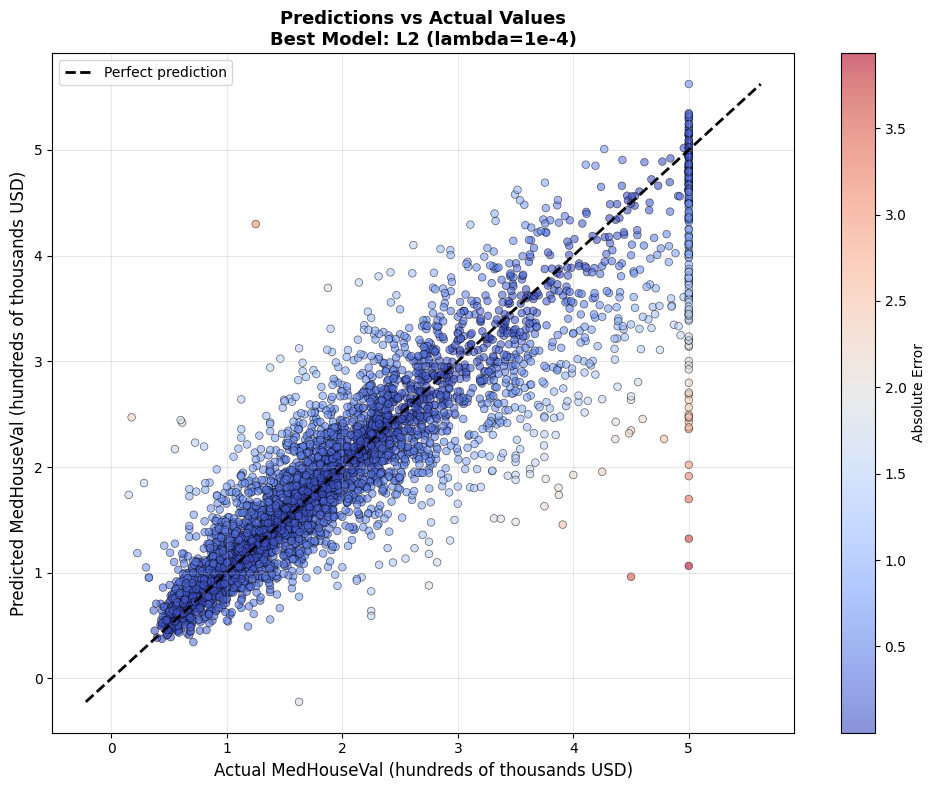


Prediction Statistics:
Mean prediction error: 0.3514
Std prediction error: 0.3869
Max prediction error: 3.9350


In [14]:
# Get best model based on lowest test RMSE
best_model = all_results[best_rmse_idx]['model']
best_label = summary_df.loc[best_rmse_idx, 'Configuration']

# Get predictions on test set
best_model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = best_model(X_batch)
        all_preds.append(y_pred.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

all_preds = np.concatenate(all_preds, axis=0).flatten()
all_targets = np.concatenate(all_targets, axis=0).flatten()

# Calculate error magnitudes for colour mapping
errors = np.abs(all_preds - all_targets)

# Create scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_targets, all_preds, c=errors, cmap='coolwarm', 
                      alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

# Add diagonal line for perfect prediction
min_val = min(all_targets.min(), all_preds.min())
max_val = max(all_targets.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual MedHouseVal (hundreds of thousands USD)', fontsize=12)
plt.ylabel('Predicted MedHouseVal (hundreds of thousands USD)', fontsize=12)
plt.title(f'Predictions vs Actual Values\nBest Model: {best_label}', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
cbar = plt.colorbar(scatter, label='Absolute Error')
plt.tight_layout()
plt.show()

print(f"\nPrediction Statistics:")
print(f"Mean prediction error: {np.mean(errors):.4f}")
print(f"Std prediction error: {np.std(errors):.4f}")
print(f"Max prediction error: {np.max(errors):.4f}")

*Your answers here.*